# 📞 Telecom Customer Churn Prediction - Complete Analysis & ML Pipeline
## Data Cleaning → EDA → Feature Engineering → Machine Learning

**Target Variable:** Customer Status (Stayed, Churned, Joined)

This notebook includes:
- Loading and merging all 3 datasets
- Comprehensive data cleaning
- Exploratory Data Analysis (EDA)
- Relationship analysis
- Feature engineering
- Multiple ML models
- Model comparison and evaluation

## 1. Import Libraries and Setup

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
#from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Utilities
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'
plt.style.use('default')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')


✅ All libraries imported successfully!


## 2. Load All Datasets

In [10]:
print('='*80)
print('\t\t\t\tLOADING DATASETS')
print('='*80)

# Load all three datasets
df_main = pd.read_csv(r"D:\About ME\Digital hub_data analysis\🙁📡 Telecom Customer Churn Prediction\telecom_customer_churn.csv")
df_zipcode = pd.read_csv(r"D:\About ME\Digital hub_data analysis\🙁📡 Telecom Customer Churn Prediction\telecom_zipcode_population.csv")
df_dictionary = pd.read_csv(r"D:\About ME\Digital hub_data analysis\🙁📡 Telecom Customer Churn Prediction\telecom_data_dictionary.csv",encoding="latin1")

print(f'\n Main Dataset: {df_main.shape}')
print(f'Zipcode Dataset: {df_zipcode.shape}')
print(f'Data Dictionary: {df_dictionary.shape}')
print('\n✅ All datasets loaded successfully!')

				LOADING DATASETS

 Main Dataset: (7043, 38)
Zipcode Dataset: (1671, 2)
Data Dictionary: (40, 3)

✅ All datasets loaded successfully!


In [11]:
# Preview main dataset
print('\n📋 Main Dataset - First 5 Rows:')
df_main.head()


📋 Main Dataset - First 5 Rows:


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [12]:
# Preview zipcode dataset
print('\n📋 Zipcode Dataset:')
df_zipcode.head()


📋 Zipcode Dataset:


,Zip Code,Population
0,90001,54492
1,90002,44586
2,90003,58198
3,90004,67852
4,90005,43019


In [13]:
# Preview data dictionary
print('\n📋 Data Dictionary:')
df_dictionary.head(10)


📋 Data Dictionary:


,Table,Field,Description
0,Customer Churn,CustomerID,A unique ID that identifies each customer
1,Customer Churn,Gender,"The customers gender: Male, Female"
2,Customer Churn,Age,"The customers current age, in years, at the t..."
3,Customer Churn,Married,"Indicates if the customer is married: Yes, No"
4,Customer Churn,Number of Dependents,Indicates the number of dependents that live w...
5,Customer Churn,City,The city of the customers primary residence i...
6,Customer Churn,Zip Code,The zip code of the customers primary residence
7,Customer Churn,Latitude,The latitude of the customers primary residence
8,Customer Churn,Longitude,The longitude of the customers primary residence
9,Customer Churn,Number of Referrals,Indicates the number of times the customer has...


## 3. Data Cleaning - Main Dataset

In [17]:
print('='*80)
print('\t\t\t\t🔍 ANALYZING MAIN DATASET')
print('='*80)
#--------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------

print(f'\nShape: {df_main.shape}')
print(f'\nData Types:')
print(df_main.dtypes.value_counts())

#--------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------

print(f'\n Missing Values:')
missing = df_main.isnull().sum()
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Percentage': (missing.values / len(df_main) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df.to_string(index=False))
print(f'\nTotal missing values: {missing.sum():,}')

				🔍 ANALYZING MAIN DATASET

Shape: (7043, 38)

Data Types:
object     23
float64     9
int64       6
Name: count, dtype: int64

 Missing Values:
                           Column  Missing_Count  Percentage
                   Churn Category           5174       73.46
                     Churn Reason           5174       73.46
                            Offer           3877       55.05
                  Online Security           1526       21.67
                    Online Backup           1526       21.67
          Avg Monthly GB Download           1526       21.67
                    Internet Type           1526       21.67
                 Streaming Movies           1526       21.67
                     Streaming TV           1526       21.67
           Device Protection Plan           1526       21.67
             Premium Tech Support           1526       21.67
                   Unlimited Data           1526       21.67
                  Streaming Music           1526       21.67

In [ ]:
# Check for duplicates
print('\n\t\t\t\t\t🔍 Checking for Duplicates:')
#--------------------------------------------------------------------------------------------------------------
print(f'Duplicate rows: {df_main.duplicated().sum()}')
if 'Customer ID' in df_main.columns:
    print(f'Duplicate Customer IDs: {df_main["Customer ID"].duplicated().sum()}')


					🔍 Checking for Duplicates:
Duplicate rows: 0
Duplicate Customer IDs: 0


In [19]:
# Clean main dataset
print('='*80)
print('\t\t\t\t\t🧹 CLEANING MAIN DATASET')
print('='*80)
#--------------------------------------------------------------------------------------------------------------

df_clean = df_main.copy()
'''
# Remove duplicates
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
if 'Customer ID' in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset='Customer ID', keep='first')
print(f'\n✓ Removed {initial_rows - len(df_clean)} duplicate rows')
'''
#--------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------
# Handle missing values
print('\n\t\t\t\t\t\t🔧 Filling missing values...')
#--------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------

# 1. Offer ->ZERO
if 'Offer' in df_clean.columns:
    df_clean['Offer'].fillna('No Offer', inplace=True)
    print('✓ Offer: Filled with "No Offer"')
#--------------------------------------------------------------------------------------------------------------

# 2. Phone-related
if 'Avg Monthly Long Distance Charges' in df_clean.columns:              #check if this col is exist
    df_clean['Avg Monthly Long Distance Charges'].fillna(0, inplace=True)# if it NaN -> this cutomer don't use long dis charges
    print('✓ Avg Monthly Long Distance Charges: Filled with 0')          #so it fill with ZERO
#                               -------------------------------------------
if 'Multiple Lines' in df_clean.columns: #هل العميل عنده أكتر من خط تليفون
    if 'Phone Service' in df_clean.columns:#عنده خدمة تليفون أصلاً
        df_clean.loc[df_clean['Multiple Lines'].isnull(), 'Multiple Lines'] = \
            df_clean.loc[df_clean['Multiple Lines'].isnull(), 'Phone Service'].apply(
                lambda x: 'No' if x == 'Yes' else 'No Phone Service'
            )
    else:
        df_clean['Multiple Lines'].fillna('No', inplace=True)
    print('✓ Multiple Lines: Filled')
#--------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------

# 3. Internet-related
internet_cols = [
    'Internet Type', 'Avg Monthly GB Download', 'Online Security', 
    'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
    'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data'
]

for col in internet_cols:
    if col in df_clean.columns:
        if col == 'Internet Type':
            df_clean[col].fillna('No Internet', inplace=True)
        elif col == 'Avg Monthly GB Download':
            df_clean[col].fillna(0, inplace=True)
        else:
            df_clean[col].fillna('No', inplace=True)
print('✓ Internet-related columns: Filled')

#-------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------

# 4. Churn-related
if 'Churn Category' in df_clean.columns:
    df_clean['Churn Category'].fillna('Not Churned', inplace=True)
    print('✓ Churn Category: Filled with "Not Churned"')

if 'Churn Reason' in df_clean.columns:
    df_clean['Churn Reason'].fillna('Not Applicable', inplace=True)
    print('✓ Churn Reason: Filled with "Not Applicable"')

print(f'\n✅ Main dataset cleaned!')
print(f'Remaining missing values: {df_clean.isnull().sum().sum()}')
print(f'Final shape: {df_clean.shape}')

					🧹 CLEANING MAIN DATASET

						🔧 Filling missing values...
✓ Offer: Filled with "No Offer"
✓ Avg Monthly Long Distance Charges: Filled with 0
✓ Multiple Lines: Filled
✓ Internet-related columns: Filled
✓ Churn Category: Filled with "Not Churned"
✓ Churn Reason: Filled with "Not Applicable"

✅ Main dataset cleaned!
Remaining missing values: 0
Final shape: (7043, 38)


## 4. Data Cleaning - Zipcode Dataset

In [20]:
print('='*80)
print('🧹 CLEANING ZIPCODE DATASET')
print('='*80)

df_zipcode_clean = df_zipcode.copy()

# Check for issues
print(f'\nShape: {df_zipcode_clean.shape}')
print(f'Duplicates: {df_zipcode_clean.duplicated().sum()}')
print(f'Missing values: {df_zipcode_clean.isnull().sum().sum()}')

# Clean
df_zipcode_clean = df_zipcode_clean.drop_duplicates()
df_zipcode_clean = df_zipcode_clean.dropna()

print(f'\n✅ Zipcode dataset cleaned!')
print(f'Final shape: {df_zipcode_clean.shape}')

🧹 CLEANING ZIPCODE DATASET

Shape: (1671, 2)
Duplicates: 0
Missing values: 0

✅ Zipcode dataset cleaned!
Final shape: (1671, 2)


In [23]:
df_clean.to_csv(r"D:\About ME\Digital hub_data analysis\🙁📡 Telecom Customer Churn Prediction\telecom_customer_churn_Cleaned.csv", index=False)

## 5. Merge Datasets

In [24]:
print('='*80)
print('🔗 MERGING DATASETS')
print('='*80)

# Merge main with zipcode
df_merged = df_clean.merge(
    df_zipcode_clean,
    on='Zip Code',
    how='left'
)

print(f'\nBefore merge: {df_clean.shape}')
print(f'After merge: {df_merged.shape}')

# Check merge success
matched = df_merged['Population'].notna().sum()
total = len(df_merged)
print(f'\nZip codes matched: {matched:,} / {total:,} ({matched/total*100:.1f}%)')

# Fill any missing Population with median
if df_merged['Population'].isnull().sum() > 0:
    median_pop = df_merged['Population'].median()
    df_merged['Population'].fillna(median_pop, inplace=True)
    print(f'Filled missing Population with median: {median_pop:,.0f}')

print(f'\n✅ Datasets merged successfully!')
print(f'Final shape: {df_merged.shape}')
print(f'Total columns: {len(df_merged.columns)}')

🔗 MERGING DATASETS

Before merge: (7043, 38)
After merge: (7043, 39)

Zip codes matched: 7,043 / 7,043 (100.0%)

✅ Datasets merged successfully!
Final shape: (7043, 39)
Total columns: 39


In [25]:
# Display merged dataset info
print('\n📊 Merged Dataset Overview:')
df_merged.head()


📊 Merged Dataset Overview:


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Population
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,65.6,593.30,0.00,0,381.51,974.81,Stayed,Not Churned,Not Applicable,4498
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,-4.0,542.40,38.33,10,96.21,610.28,Stayed,Not Churned,Not Applicable,31297
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,62069
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,46677
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,42853


In [26]:
# Final check for missing values
print('\n🔍 Final Missing Values Check:')
missing_final = df_merged.isnull().sum()
if missing_final.sum() > 0:
    print(missing_final[missing_final > 0])
else:
    print('✅ No missing values!')


🔍 Final Missing Values Check:
✅ No missing values!


## 6. Exploratory Data Analysis (EDA)

In [27]:
print('='*80)
print('📊 EXPLORATORY DATA ANALYSIS')
print('='*80)

# Basic statistics
print(f'\nDataset Shape: {df_merged.shape}')
print(f'Total Customers: {len(df_merged):,}')

# Target variable distribution
if 'Customer Status' in df_merged.columns:
    print(f'\n📈 Customer Status Distribution:')
    status_counts = df_merged['Customer Status'].value_counts()
    for status, count in status_counts.items():
        pct = count / len(df_merged) * 100
        print(f'  {status}: {count:,} ({pct:.2f}%)')

📊 EXPLORATORY DATA ANALYSIS

Dataset Shape: (7043, 39)
Total Customers: 7,043

📈 Customer Status Distribution:
  Stayed: 4,720 (67.02%)
  Churned: 1,869 (26.54%)
  Joined: 454 (6.45%)


In [28]:
# Numeric columns summary
print('\n📊 Numeric Columns Summary:')
df_merged.describe()


📊 Numeric Columns Summary:


,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Population
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,22.958954,20.515405,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056,22139.603294
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,15.448113,20.418940,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542,21152.392837
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,0.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000,11.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,9.210000,3.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000,2344.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,22.890000,17.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000,17554.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,36125.000000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,105285.000000


In [29]:
# Categorical columns summary
print('\n📊 Categorical Columns:')
categorical_cols = df_merged.select_dtypes(include=['object']).columns
print(f'Total categorical columns: {len(categorical_cols)}')
print(f'\nColumns: {list(categorical_cols[:10])}...')


📊 Categorical Columns:
Total categorical columns: 23

Columns: ['Customer ID', 'Gender', 'Married', 'City', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security']...


### 6.1 Target Variable Analysis

✅ Saved: 01_customer_status_distribution.png


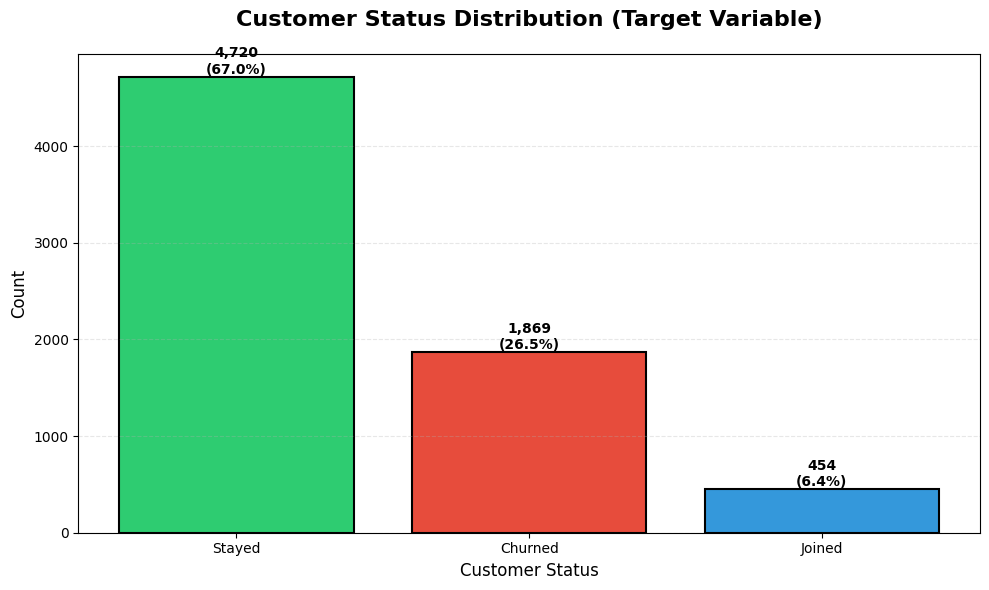

In [30]:
# Customer Status Distribution Plot
if 'Customer Status' in df_merged.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    status_counts = df_merged['Customer Status'].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    
    bars = ax.bar(status_counts.index, status_counts.values, 
                  color=colors[:len(status_counts)], edgecolor='black', linewidth=1.5)
    
    ax.set_title('Customer Status Distribution (Target Variable)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Customer Status', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}\n({int(height)/len(df_merged)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('01_customer_status_distribution.png', dpi=100, bbox_inches='tight')
    plt.close()
    print('✅ Saved: 01_customer_status_distribution.png')
    
    from IPython.display import Image, display
    display(Image('01_customer_status_distribution.png'))

### 6.2 Numeric Features Distribution

✅ Saved: 02_numeric_distributions.png


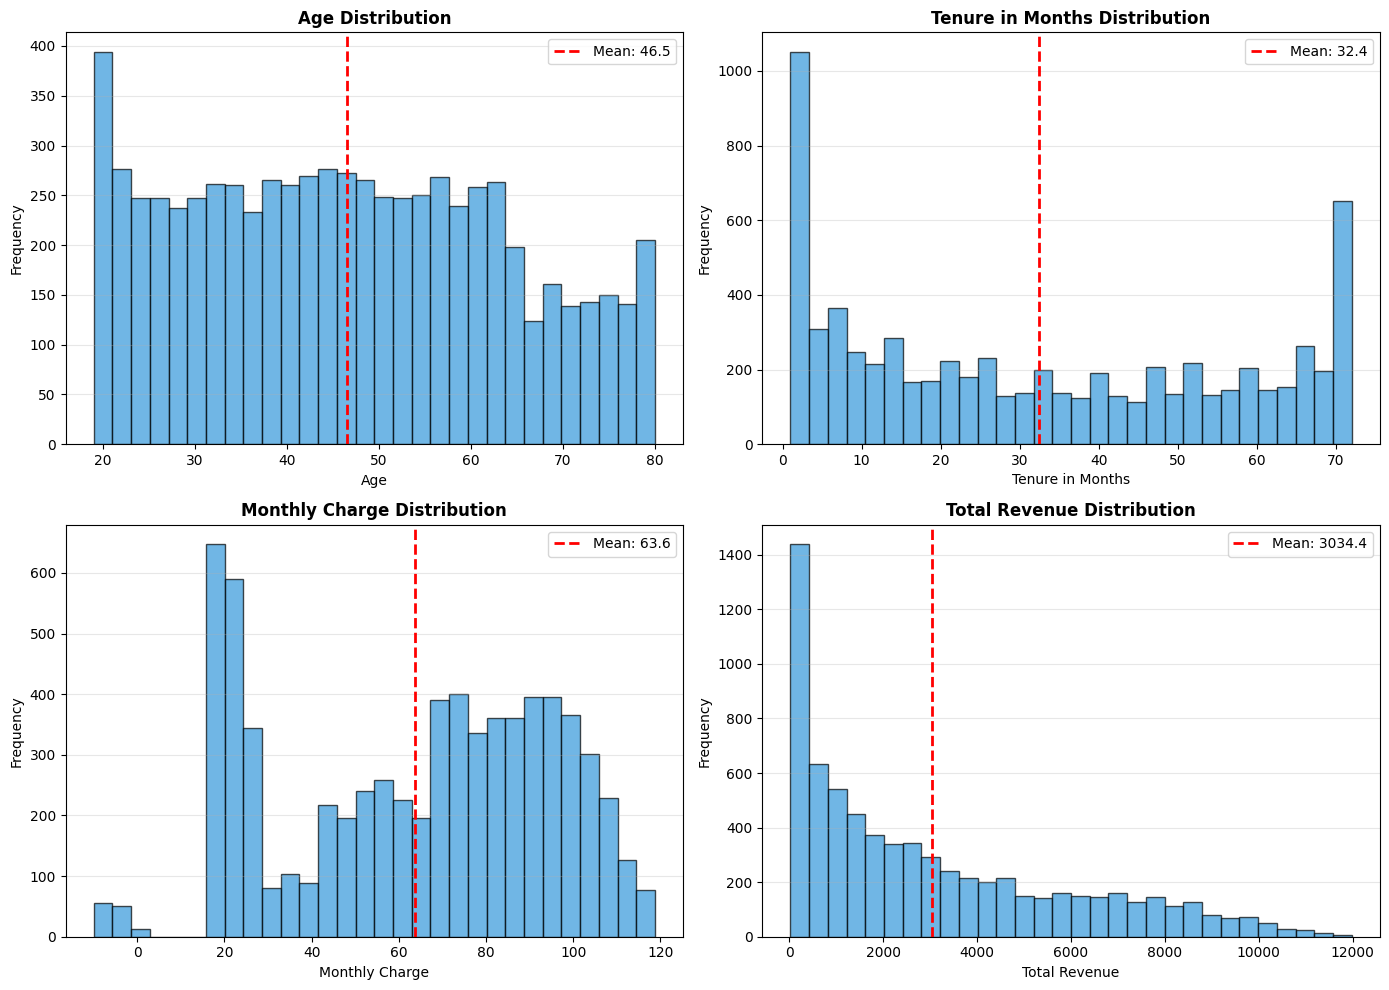

In [17]:
# Key numeric features
key_numeric = ['Age', 'Tenure in Months', 'Monthly Charge', 'Total Revenue', 
               'Number of Referrals', 'Total Charges']

available_numeric = [col for col in key_numeric if col in df_merged.columns]

if len(available_numeric) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(available_numeric[:4]):
        axes[idx].hist(df_merged[col].dropna(), bins=30, color='#3498db', 
                      edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        
        mean_val = df_merged[col].mean()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                         label=f'Mean: {mean_val:.1f}')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.savefig('02_numeric_distributions.png', dpi=100, bbox_inches='tight')
    plt.close()
    print('✅ Saved: 02_numeric_distributions.png')
    
    from IPython.display import Image, display
    display(Image('02_numeric_distributions.png'))

### 6.3 Categorical Features Analysis

✅ Saved: 03_categorical_distributions.png


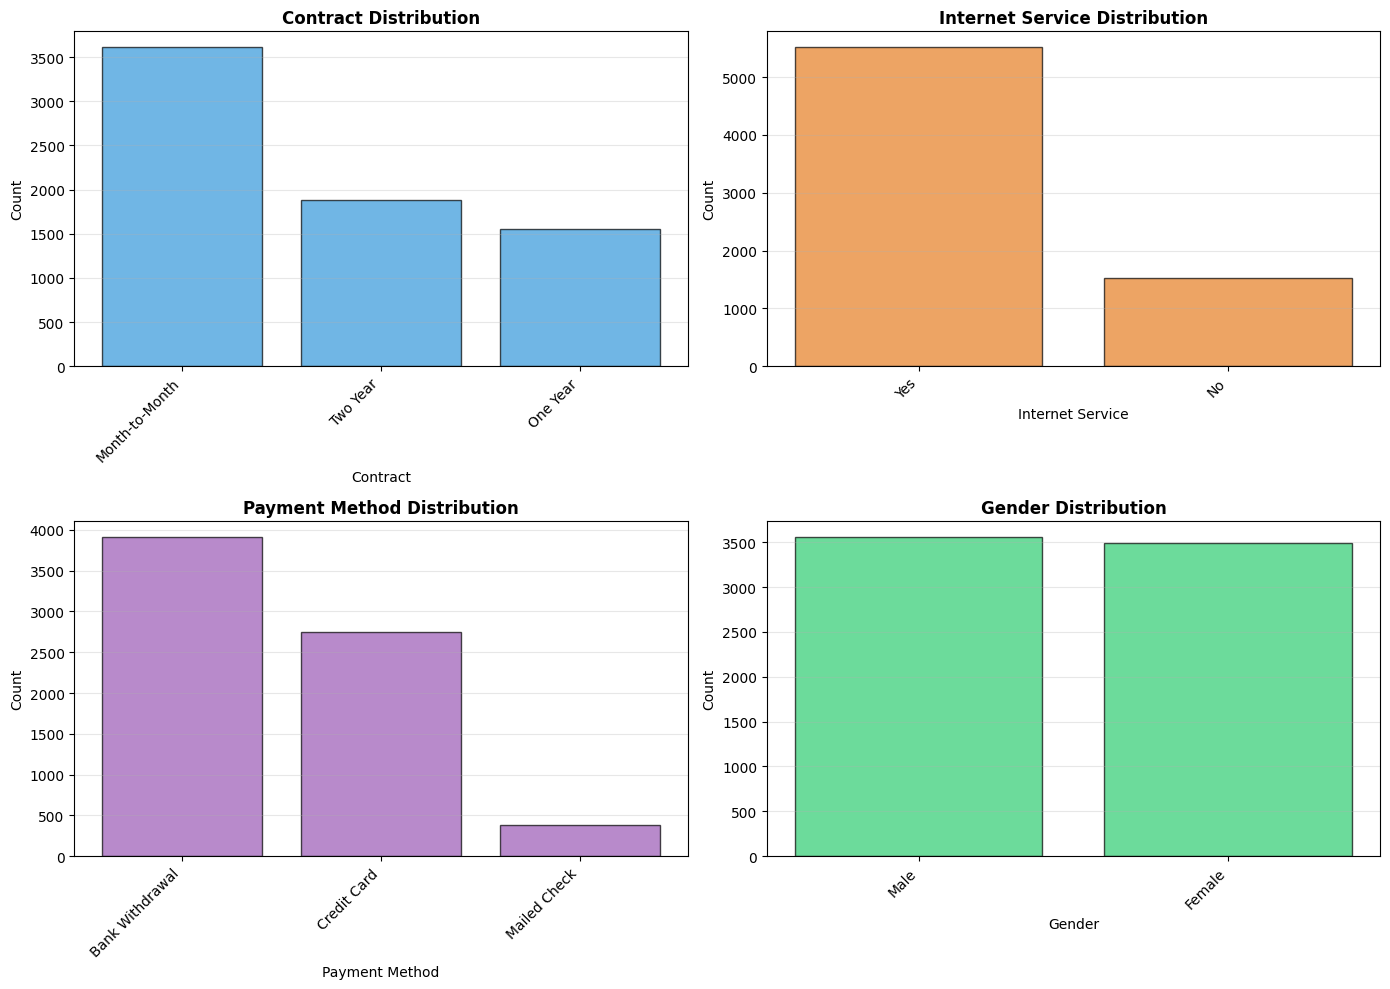

In [18]:
# Key categorical features
key_categorical = ['Contract', 'Internet Service', 'Payment Method', 'Gender']
available_categorical = [col for col in key_categorical if col in df_merged.columns]

if len(available_categorical) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    colors_list = ['#3498db', '#e67e22', '#9b59b6', '#2ecc71']
    
    for idx, col in enumerate(available_categorical[:4]):
        counts = df_merged[col].value_counts()
        axes[idx].bar(range(len(counts)), counts.values, 
                     color=colors_list[idx], edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Count', fontsize=10)
        axes[idx].set_xticks(range(len(counts)))
        axes[idx].set_xticklabels(counts.index, rotation=45, ha='right')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('03_categorical_distributions.png', dpi=100, bbox_inches='tight')
    plt.close()
    print('✅ Saved: 03_categorical_distributions.png')
    
    from IPython.display import Image, display
    display(Image('03_categorical_distributions.png'))

## 7. Relationship Analysis

### 7.1 Correlation Analysis (Numeric Features)

✅ Saved: 04_correlation_heatmap.png


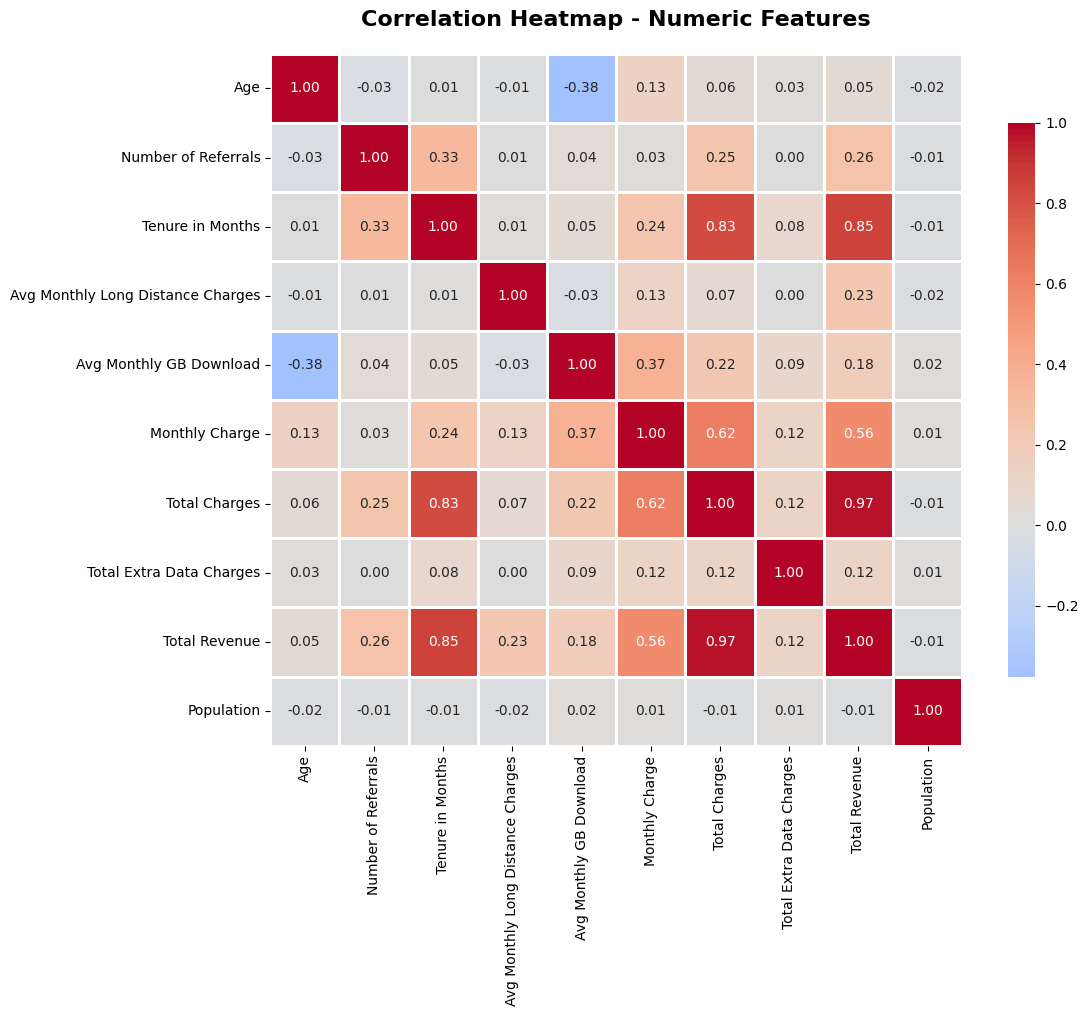

In [31]:
# Correlation heatmap
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()

# Select key numeric columns
key_cols = [col for col in numeric_cols if col in [
    'Age', 'Tenure in Months', 'Monthly Charge', 'Total Revenue',
    'Total Charges', 'Number of Referrals', 'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download', 'Total Extra Data Charges', 'Population'
]]

if len(key_cols) > 2:
    fig, ax = plt.subplots(figsize=(12, 10))
    corr_matrix = df_merged[key_cols].corr()
    
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, ax=ax,
                cbar_kws={'shrink': 0.8})
    
    ax.set_title('Correlation Heatmap - Numeric Features', 
                fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('04_correlation_heatmap.png', dpi=100, bbox_inches='tight')
    plt.close()
    print('✅ Saved: 04_correlation_heatmap.png')
    
    from IPython.display import Image, display
    display(Image('04_correlation_heatmap.png'))

In [32]:
# Identify strong correlations
if len(key_cols) > 2:
    print('\n🔍 Strong Correlations (|correlation| > 0.7):')
    print('='*60)
    
    # Get upper triangle of correlation matrix
    corr_matrix = df_merged[key_cols].corr()
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Find strong correlations
    strong_corr = []
    for column in upper_tri.columns:
        for idx in upper_tri.index:
            value = upper_tri.loc[idx, column]
            if pd.notna(value) and abs(value) > 0.7:
                strong_corr.append((idx, column, value))
    
    if strong_corr:
        for feat1, feat2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
            print(f'{feat1} <-> {feat2}: {corr:.3f}')
    else:
        print('No strong correlations found (all < 0.7)')


🔍 Strong Correlations (|correlation| > 0.7):
Total Charges <-> Total Revenue: 0.972
Tenure in Months <-> Total Revenue: 0.853
Tenure in Months <-> Total Charges: 0.826


## 8. Feature Engineering

In [33]:
print('='*80)
print('🔧 FEATURE ENGINEERING')
print('='*80)

df_features = df_merged.copy()

# 1. Create tenure categories
if 'Tenure in Months' in df_features.columns:
    df_features['Tenure_Category'] = pd.cut(
        df_features['Tenure in Months'],
        bins=[0, 12, 24, 48, 100],
        labels=['0-1 Year', '1-2 Years', '2-4 Years', '4+ Years']
    )
    print('✓ Created Tenure_Category')

# 2. Create age categories
if 'Age' in df_features.columns:
    df_features['Age_Category'] = pd.cut(
        df_features['Age'],
        bins=[0, 30, 45, 60, 100],
        labels=['Young', 'Middle-aged', 'Senior', 'Elderly']
    )
    print('✓ Created Age_Category')

# 3. Create charge per month category
if 'Monthly Charge' in df_features.columns:
    df_features['Charge_Category'] = pd.cut(
        df_features['Monthly Charge'],
        bins=[0, 30, 60, 90, 200],
        labels=['Low', 'Medium', 'High', 'Very High']
    )
    print('✓ Created Charge_Category')

# 4. Total services count
service_cols = ['Phone Service', 'Internet Service', 'Online Security', 
                'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
                'Streaming TV', 'Streaming Movies']
available_services = [col for col in service_cols if col in df_features.columns]

if available_services:
    df_features['Total_Services'] = 0
    for col in available_services:
        df_features['Total_Services'] += (df_features[col] == 'Yes').astype(int)
    print('✓ Created Total_Services')

# 5. Has any streaming service
streaming_cols = ['Streaming TV', 'Streaming Movies', 'Streaming Music']
available_streaming = [col for col in streaming_cols if col in df_features.columns]

if available_streaming:
    df_features['Has_Streaming'] = 0
    for col in available_streaming:
        df_features['Has_Streaming'] = (
            (df_features['Has_Streaming'] == 1) | (df_features[col] == 'Yes')
        ).astype(int)
    print('✓ Created Has_Streaming')

# 6. Revenue per month
if 'Total Revenue' in df_features.columns and 'Tenure in Months' in df_features.columns:
    df_features['Revenue_Per_Month'] = df_features['Total Revenue'] / (df_features['Tenure in Months'] + 1)
    print('✓ Created Revenue_Per_Month')

# 7. Has dependents flag
if 'Number of Dependents' in df_features.columns:
    df_features['Has_Dependents'] = (df_features['Number of Dependents'] > 0).astype(int)
    print('✓ Created Has_Dependents')

print(f'\n✅ Feature engineering complete!')
print(f'New shape: {df_features.shape}')
print(f'New features created: {df_features.shape[1] - df_merged.shape[1]}')

🔧 FEATURE ENGINEERING
✓ Created Tenure_Category
✓ Created Age_Category
✓ Created Charge_Category
✓ Created Total_Services
✓ Created Has_Streaming
✓ Created Revenue_Per_Month
✓ Created Has_Dependents

✅ Feature engineering complete!
New shape: (7043, 46)
New features created: 7


## 9. Prepare Data for Machine Learning

In [34]:
print('='*80)
print('🎯 PREPARING DATA FOR ML')
print('='*80)

# Create a copy for modeling
df_model = df_features.copy()

# Remove non-predictive columns
cols_to_drop = ['Customer ID', 'Zip Code', 'Latitude', 'Longitude', 
                'Churn Category', 'Churn Reason', 'City']
cols_to_drop = [col for col in cols_to_drop if col in df_model.columns]

df_model = df_model.drop(columns=cols_to_drop)
print(f'\n✓ Dropped non-predictive columns: {len(cols_to_drop)}')

# Separate features and target
if 'Customer Status' in df_model.columns:
    X = df_model.drop('Customer Status', axis=1)
    y = df_model['Customer Status']
    
    print(f'\n✓ Target variable: Customer Status')
    print(f'  Classes: {y.unique()}')
    print(f'  Distribution:')
    for status, count in y.value_counts().items():
        print(f'    {status}: {count} ({count/len(y)*100:.1f}%)')
else:
    print('\n❌ Customer Status column not found!')
    X = df_model
    y = None

🎯 PREPARING DATA FOR ML

✓ Dropped non-predictive columns: 7

✓ Target variable: Customer Status
  Classes: ['Stayed' 'Churned' 'Joined']
  Distribution:
    Stayed: 4720 (67.0%)
    Churned: 1869 (26.5%)
    Joined: 454 (6.4%)


In [35]:
# Encode categorical variables
print('\n🔧 Encoding categorical variables...')

categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Categorical features: {len(categorical_features)}')

# Label encode categorical features
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f'✓ Encoded {len(categorical_features)} categorical features')

# Encode target variable
if y is not None:
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    print(f'\n✓ Target variable encoded')
    print(f'  Mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')
else:
    y_encoded = None


🔧 Encoding categorical variables...
Categorical features: 21
✓ Encoded 21 categorical features

✓ Target variable encoded
  Mapping: {'Churned': np.int64(0), 'Joined': np.int64(1), 'Stayed': np.int64(2)}


In [36]:
# Handle any remaining missing values
if X.isnull().sum().sum() > 0:
    print('\n🔧 Handling remaining missing values...')
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    print('✓ Missing values imputed')

print(f'\n📊 Final dataset for ML:')
print(f'  Features shape: {X.shape}')
print(f'  Target shape: {y_encoded.shape if y_encoded is not None else "N/A"}')
print(f'  Total features: {X.shape[1]}')
#print(X.isna().sum())


📊 Final dataset for ML:
  Features shape: (7043, 38)
  Target shape: (7043,)
  Total features: 38


In [37]:
# Display feature list
print('\n📋 Features for modeling:')
print(f'Total: {len(X.columns)}')
print('\nFirst 20 features:')
for i, col in enumerate(X.columns[:20], 1):
    print(f'{i:2d}. {col}')
if len(X.columns) > 20:
    print(f'... and {len(X.columns) - 20} more')


📋 Features for modeling:
Total: 38

First 20 features:
 1. Gender
 2. Age
 3. Married
 4. Number of Dependents
 5. Number of Referrals
 6. Tenure in Months
 7. Offer
 8. Phone Service
 9. Avg Monthly Long Distance Charges
10. Multiple Lines
11. Internet Service
12. Internet Type
13. Avg Monthly GB Download
14. Online Security
15. Online Backup
16. Device Protection Plan
17. Premium Tech Support
18. Streaming TV
19. Streaming Movies
20. Streaming Music
... and 18 more


## 10. Train-Test Split

In [38]:
print('='*80)
print('✂️  TRAIN-TEST SPLIT')
print('='*80)

if y_encoded is not None:
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_encoded
    )
    
    print(f'\n✓ Data split successfully')
    print(f'  Training set: {X_train.shape}')
    print(f'  Test set: {X_test.shape}')
    
    # Check class distribution
    print(f'\n📊 Class distribution:')
    print(f'  Training:')
    train_dist = pd.Series(y_train).value_counts(normalize=True) * 100
    for class_idx, pct in train_dist.items():
        class_name = le_target.inverse_transform([class_idx])[0]
        print(f'    {class_name}: {pct:.1f}%')
    
    print(f'  Test:')
    test_dist = pd.Series(y_test).value_counts(normalize=True) * 100
    for class_idx, pct in test_dist.items():
        class_name = le_target.inverse_transform([class_idx])[0]
        print(f'    {class_name}: {pct:.1f}%')
else:
    print('\n❌ Cannot split: Target variable not available')

✂️  TRAIN-TEST SPLIT

✓ Data split successfully
  Training set: (5634, 38)
  Test set: (1409, 38)

📊 Class distribution:
  Training:
    Stayed: 67.0%
    Churned: 26.5%
    Joined: 6.4%
  Test:
    Stayed: 67.0%
    Churned: 26.5%
    Joined: 6.5%


## 11. Feature Scaling

In [39]:
print('='*80)
print('📏 FEATURE SCALING')
print('='*80)

if y_encoded is not None:
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f'\n✓ Features scaled using StandardScaler')
    print(f'  Scaled training data shape: {X_train_scaled.shape}')
    print(f'  Scaled test data shape: {X_test_scaled.shape}')
else:
    print('\n❌ Cannot scale: Data not split')

📏 FEATURE SCALING

✓ Features scaled using StandardScaler
  Scaled training data shape: (5634, 38)
  Scaled test data shape: (1409, 38)


## 12. Machine Learning Models

In [40]:
print('='*80)
print('🤖 TRAINING MACHINE LEARNING MODELS')
print('='*80)

if y_encoded is not None:
    # Define models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
        'Naive Bayes': GaussianNB()
    }
    
    print(f'\nTraining {len(models)} models...')
    print('This may take a few minutes...\n')
    
    results = []
    trained_models = {}
    
    for name, model in models.items():
        print(f'Training {name}...', end=' ')
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Predictions
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled) if hasattr(model, 'predict_proba') else None
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # ROC AUC (for multiclass)
        try:
            if y_pred_proba is not None:
                roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            else:
                roc_auc = 0.0
        except:
            roc_auc = 0.0
        
        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc
        })
        
        trained_models[name] = model
        
        print(f'✓ (Accuracy: {accuracy:.4f})')
    
    print(f'\n✅ All models trained successfully!')
else:
    print('\n❌ Cannot train models: Data not prepared')
    results = []

🤖 TRAINING MACHINE LEARNING MODELS

Training 6 models...
This may take a few minutes...

Training Logistic Regression... ✓ (Accuracy: 0.8353)
Training Decision Tree... ✓ (Accuracy: 0.7807)
Training Random Forest... ✓ (Accuracy: 0.8432)
Training Gradient Boosting... ✓ (Accuracy: 0.8531)
Training K-Nearest Neighbors... ✓ (Accuracy: 0.7622)
Training Naive Bayes... ✓ (Accuracy: 0.7211)

✅ All models trained successfully!


## 13. Model Comparison

In [41]:
if results:
    # Create results dataframe
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False)
    
    print('='*80)
    print('🏆 MODEL PERFORMANCE COMPARISON')
    print('='*80)
    print('\n')
    print(results_df.to_string(index=False))
    
    # Best model
    best_model_name = results_df.iloc[0]['Model']
    best_accuracy = results_df.iloc[0]['Accuracy']
    print(f'\n🥇 Best Model: {best_model_name} (Accuracy: {best_accuracy:.4f})')

🏆 MODEL PERFORMANCE COMPARISON


              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
  Gradient Boosting  0.853087   0.848740 0.853087  0.850123 0.948411
      Random Forest  0.843151   0.837343 0.843151  0.838989 0.936209
Logistic Regression  0.835344   0.836048 0.835344  0.835578 0.932659
      Decision Tree  0.780696   0.789215 0.780696  0.784199 0.796322
K-Nearest Neighbors  0.762243   0.768448 0.762243  0.763791 0.852172
        Naive Bayes  0.721079   0.781248 0.721079  0.738545 0.857358

🥇 Best Model: Gradient Boosting (Accuracy: 0.8531)


## 14. Best Model Analysis

In [43]:
if results and y_encoded is not None:
    # Get best model
    best_model = trained_models[best_model_name]
    
    print('='*80)
    print(f'🔍 DETAILED ANALYSIS: {best_model_name.upper()}')
    print('='*80)
    
    # Predictions
    y_pred_best = best_model.predict(X_test_scaled)
    
    # Classification report
    print('\n📊 Classification Report:')
    print('-'*80)
    print(classification_report(y_test, y_pred_best, 
                               target_names=le_target.classes_,
                               zero_division=0))

🔍 DETAILED ANALYSIS: GRADIENT BOOSTING

📊 Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Churned       0.74      0.69      0.71       374
      Joined       0.75      0.64      0.69        91
      Stayed       0.90      0.94      0.92       944

    accuracy                           0.85      1409
   macro avg       0.80      0.76      0.77      1409
weighted avg       0.85      0.85      0.85      1409




✅ Saved: 10_confusion_matrix.png


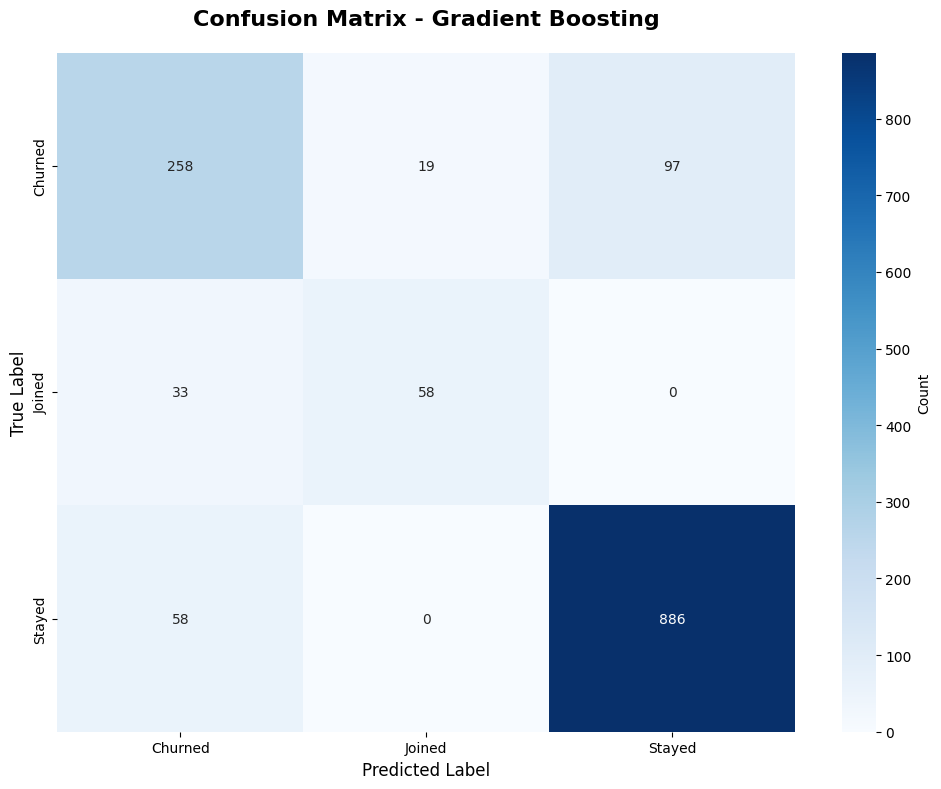

In [44]:
# Confusion Matrix
if results and y_encoded is not None:
    cm = confusion_matrix(y_test, y_pred_best)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_,
                ax=ax, cbar_kws={'label': 'Count'})
    
    ax.set_title(f'Confusion Matrix - {best_model_name}', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('10_confusion_matrix.png', dpi=100, bbox_inches='tight')
    plt.close()
    print('\n✅ Saved: 10_confusion_matrix.png')
    
    from IPython.display import Image, display
    display(Image('10_confusion_matrix.png'))


📊 Feature Importance Analysis:
--------------------------------------------------------------------------------

Top 15 Most Important Features:
                    Feature  Importance
           Tenure in Months    0.426443
                   Contract    0.203531
        Number of Referrals    0.087105
             Monthly Charge    0.076906
                        Age    0.055049
       Number of Dependents    0.015851
             Has_Dependents    0.015478
              Total Charges    0.014049
                 Population    0.013967
             Payment Method    0.012587
              Total Revenue    0.010619
          Paperless Billing    0.008736
Total Long Distance Charges    0.008070
    Avg Monthly GB Download    0.007910
          Revenue_Per_Month    0.006996

✅ Saved: 11_feature_importance.png


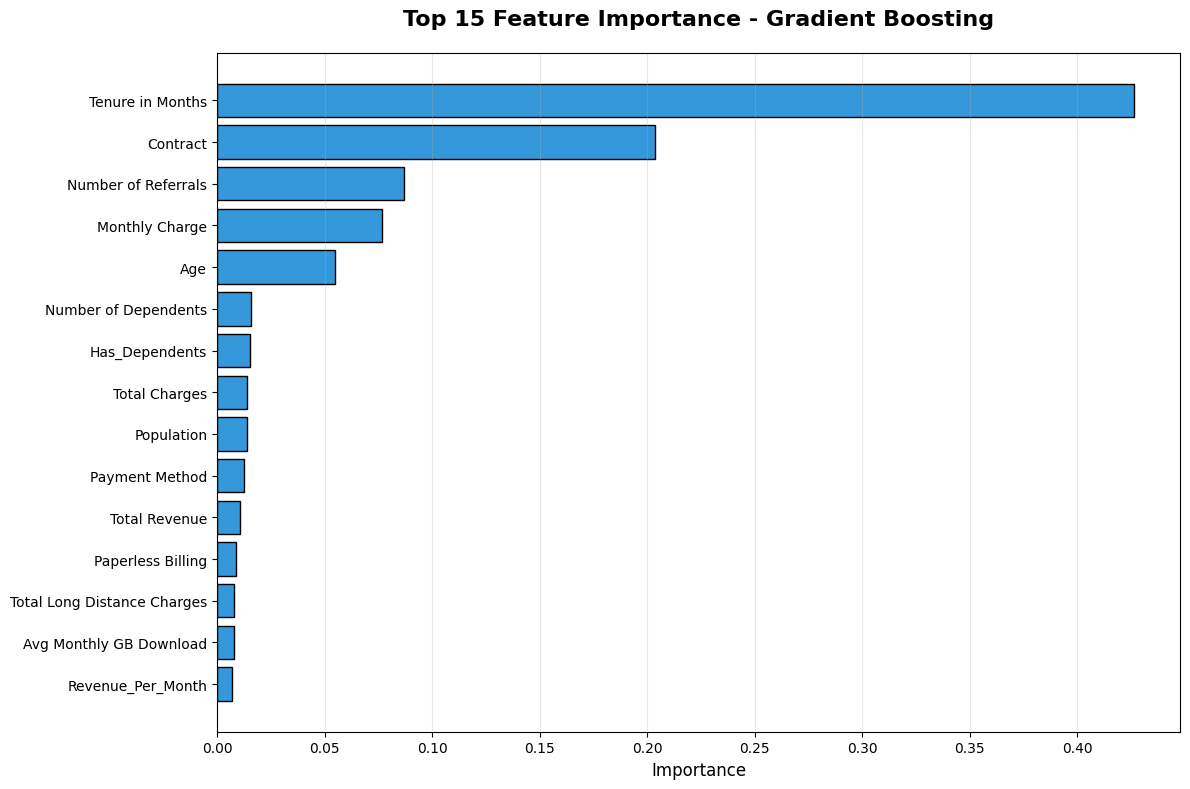

In [45]:
# Feature Importance (for tree-based models)
if results and hasattr(best_model, 'feature_importances_'):
    print('\n📊 Feature Importance Analysis:')
    print('-'*80)
    
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print('\nTop 15 Most Important Features:')
    print(feature_importance.head(15).to_string(index=False))
    
    # Plot feature importance
    fig, ax = plt.subplots(figsize=(12, 8))
    top_features = feature_importance.head(15)
    ax.barh(range(len(top_features)), top_features['Importance'], 
            color='#3498db', edgecolor='black')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'])
    ax.invert_yaxis()
    ax.set_title(f'Top 15 Feature Importance - {best_model_name}', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Importance', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('11_feature_importance.png', dpi=100, bbox_inches='tight')
    plt.close()
    print('\n✅ Saved: 11_feature_importance.png')
    
    from IPython.display import Image, display
    display(Image('11_feature_importance.png'))

## 15. Save Results

In [46]:
print('='*80)
print('💾 SAVING RESULTS')
print('='*80)

# Save cleaned and merged dataset
df_merged.to_csv('telecom_cleaned_merged.csv', index=False)
print('\n✓ Saved: telecom_cleaned_merged.csv')


💾 SAVING RESULTS

✓ Saved: telecom_cleaned_merged.csv


## 16. Final Summary

In [48]:
print('='*80)
print('📊 FINAL SUMMARY REPORT')
print('='*80)

print(f'\n1️⃣ DATA PROCESSING:')
print(f'   • Main dataset: {df_main.shape}')
print(f'   • Zipcode dataset: {df_zipcode.shape}')
print(f'   • Merged dataset: {df_merged.shape}')
print(f'   • Final modeling dataset: {X.shape if y_encoded is not None else "N/A"}')

if 'Customer Status' in df_merged.columns:
    print(f'\n2️⃣ TARGET VARIABLE:')
    print(f'   • Variable: Customer Status')
    for status, count in df_merged['Customer Status'].value_counts().items():
        pct = count / len(df_merged) * 100
        print(f'   • {status}: {count:,} ({pct:.1f}%)')

print(f'\n3️⃣ FEATURE ENGINEERING:')
print(f'   • Original features: {df_merged.shape[1]}')
print(f'   • Engineered features: {df_features.shape[1] - df_merged.shape[1]}')
print(f'   • Final features for ML: {X.shape[1] if y_encoded is not None else "N/A"}')

if results:
    print(f'\n4️⃣ MACHINE LEARNING:')
    print(f'   • Models trained: {len(results)}')
    print(f'   • Best model: {best_model_name}')
    print(f'   • Best accuracy: {best_accuracy:.4f}')
    print(f'   • Training set size: {len(X_train):,}')
    print(f'   • Test set size: {len(X_test):,}')

print(f'\n5️⃣ VISUALIZATIONS CREATED:')
print(f'   • Customer status distribution')
print(f'   • Numeric feature distributions')
print(f'   • Categorical feature distributions')
print(f'   • Correlation heatmap')
print(f'   • Relationship plots (5+)')
if results:
    print(f'   • Model comparison charts')
    print(f'   • Confusion matrix')
    if hasattr(best_model, 'feature_importances_'):
        print(f'   • Feature importance chart')

print(f'\n6️⃣ OUTPUT FILES:')
print(f'   • telecom_cleaned_merged.csv')
if results:
    print(f'   • model_comparison_results.csv')
    if hasattr(best_model, 'feature_importances_'):
        print(f'   • feature_importance.csv')
print(f'   • 11+ visualization PNG files')

print('\n' + '='*80)
print('🎉 ANALYSIS COMPLETE!')
print('='*80)
print(f'\n✅ All datasets cleaned')
print(f'✅ Relationships analyzed')
print(f'✅ Features engineered')
if results:
    print(f'✅ {len(results)} ML models trained and compared')
print(f'✅ Results saved')

📊 FINAL SUMMARY REPORT

1️⃣ DATA PROCESSING:
   • Main dataset: (7043, 38)
   • Zipcode dataset: (1671, 2)
   • Merged dataset: (7043, 39)
   • Final modeling dataset: (7043, 38)

2️⃣ TARGET VARIABLE:
   • Variable: Customer Status
   • Stayed: 4,720 (67.0%)
   • Churned: 1,869 (26.5%)
   • Joined: 454 (6.4%)

3️⃣ FEATURE ENGINEERING:
   • Original features: 39
   • Engineered features: 7
   • Final features for ML: 38

4️⃣ MACHINE LEARNING:
   • Models trained: 6
   • Best model: Gradient Boosting
   • Best accuracy: 0.8531
   • Training set size: 5,634
   • Test set size: 1,409

5️⃣ VISUALIZATIONS CREATED:
   • Customer status distribution
   • Numeric feature distributions
   • Categorical feature distributions
   • Correlation heatmap
   • Relationship plots (5+)
   • Model comparison charts
   • Confusion matrix
   • Feature importance chart

6️⃣ OUTPUT FILES:
   • telecom_cleaned_merged.csv
   • model_comparison_results.csv
   • feature_importance.csv
   • 11+ visualization PNG f